In [47]:
## IMPORTS AND SETUP
# Jupyter Notebook setup
%load_ext autoreload
%autoreload 2

# Imports
import os
import sys
sys.path.insert(0, "/tf/projet") # Add the project root directory to the Python path (docker hosting)

# Imports
import json
import wandb
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from Leyanda_Project.utils.warning_clean import silence_tensorflow_warnings
from Leyanda_Project.models.callbacks import create_callbacks, BLEUCallback
from Leyanda_Project.preprocessing.captioning_preprocessing import load_coco_dataset, create_tokenizer, create_dataset_generator, split_dataset
from Leyanda_Project.models.captioning_models import create_image_encoder, create_caption_decoder, create_captioning_model, generate_caption, basic_loss, semantic_loss, plot_training_history
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.applications.inception_v3 import InceptionV3


# Suppress warnings
silence_tensorflow_warnings()

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU is available: {len(gpus)} device(s) detected")
    except RuntimeError as e:
        print("Error configuring GPU:", str(e))
else:
    print("No GPU available, using CPU")

# Wandb setup
if not os.path.exists("/tf/projet/.env"):
    print("WARNING: No .env file found, please create one with your Wandb API key.")
    exit(1)
else:
    load_dotenv("/tf/projet/.env")
    WANDB_API_KEY = os.getenv("API_KEY")
    wandb_entity = "tom-antoine-cesi"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TensorFlow warnings suppression is active.
GPU is available: 1 device(s) detected


In [48]:
## PARAMETERS
seed = 123
project_name = "Leyanda"
np.random.seed(seed)
tf.random.set_seed(seed)

# Dataset loading parameters
raw_data_path = "/tf/projet/Dataset_livrable_3"  # Path to the raw data folder
images_folder = os.path.join(raw_data_path, "train2017")  # Path to the images folder
annotations_folder = os.path.join(raw_data_path, "annotations")  # Path to the annotations folder
max_samples = 6000 # Maximum number of samples to load for testing
shuffle = False # Shuffle the dataset or not
batch_size = 64  # Batch size for dataset loading
max_length = 30  # Maximum caption length
vocab_size_limit = 20000  # Maximum vocabulary size

# Dataset split parameters
train_split = 0.8  # Proportion of the dataset to use for training
val_split = 0.1  # Proportion of the dataset to use for validation

# Model parameters
embedding_dim = 256  # Dimension of word embeddings
units = 512  # Number of units in LSTM layers
epochs = 5  # Number of epochs for training
save_path = "/tf/projet/Leyanda_Project/models/saved/L3" # Path to the models folder
loss_function = semantic_loss # Loss function to use for training, can be 'basic_loss' or 'semantic_loss'
BLEU = False # Whether to use BLEU score for evaluation

In [ ]:
## DATA PREPARATION WORKFLOW
print(f"Starting data preparation workflow for {project_name}...")

# 1. Load COCO dataset
image_paths, captions = load_coco_dataset(
    images_folder=images_folder,
    annotations_folder=annotations_folder,
    annotation_file="captions_train2017.json"
)

# 2. Limit dataset size for testing (remove for full training)
if len(image_paths) > max_samples:
    print(f"Limiting dataset to {max_samples} samples for testing")
    random_indices = np.random.choice(len(image_paths), max_samples, replace=False)
    image_paths = [image_paths[i] for i in random_indices]
    captions = [captions[i] for i in random_indices]

# 3. Create and fit tokenizer
tokenizer, vocab_size = create_tokenizer(captions, num_words=vocab_size_limit)

# 4. Split dataset
(train_img_paths, train_captions,
 val_img_paths, val_captions,
 test_img_paths, test_captions) = split_dataset(
    image_paths,
    captions,
    train_split=train_split,
    val_split=val_split
)

# 5. Create TensorFlow datasets
print("Creating TensorFlow datasets...")
train_dataset = create_dataset_generator(
    train_img_paths,
    train_captions,
    tokenizer,
    max_length=max_length,
    batch_size=batch_size,
    shuffle=shuffle
)

val_dataset = create_dataset_generator(
    val_img_paths,
    val_captions,
    tokenizer,
    max_length=max_length,
    batch_size=batch_size,
    shuffle=shuffle
)

test_dataset = create_dataset_generator(
    test_img_paths,
    test_captions,
    tokenizer,
    max_length=max_length,
    batch_size=batch_size,
    shuffle=shuffle
)

for (images, captions_input), captions_target in train_dataset.take(1):
    print(f"Image batch shape: {images.shape}")
    print(f"Captions input shape: {captions_input.shape}")
    print(f"Captions target shape: {captions_target.shape}")
    break

print("Data preparation complete!")

Starting data preparation workflow for Leyanda...
Loading COCO dataset from /tf/projet/Dataset_livrable_3/train2017 and /tf/projet/Dataset_livrable_3/annotations...


In [42]:
## MODELS CREATION WORKFLOW
print(f"Starting model creation workflow for {project_name}...")

# Initialize wandb
wandb.init(
    project=project_name,
    name=f"captioning_model_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}",
    entity=wandb_entity,
    config={
        "architecture": "InceptionV3-LSTM",
        "dataset": "COCO",
        "embedding_dim": embedding_dim,
        "units": units,
        "max_length": max_length,
        "vocab_size": len(tokenizer.word_index) + 1,
        "batch_size": batch_size
    }
)

# 1. Create encoder model
print("Creating image encoder...")
encoder = create_image_encoder(input_shape=(180, 180, 3), embedding_dim=embedding_dim)

# 2. Create decoder model
vocab_size = len(tokenizer.word_index) + 1
print(f"Creating caption decoder with vocabulary size: {vocab_size}")
decoder = create_caption_decoder(
    vocab_size=vocab_size,
    max_length=max_length,
    embedding_dim=embedding_dim,
    units=units
)

# 3. Create the complete captioning model
print("Creating captioning model...")
captioning_model = create_captioning_model(encoder, decoder, max_length)

# 4. Compile the model
print("Compiling the model...")
captioning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=['accuracy']
)

# Display model summary
print("Model architecture summary:")
captioning_model.summary()

print("Models created successfully!")

Starting model creation workflow for Leyanda...


epoch/accuracy,▁▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
epoch/epoch,▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁
epoch/val_accuracy,▁▃▄▄▅▅▅▅▆▆▇▇███████
epoch/val_loss,█▆▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁
final_test_accuracy,▁
final_test_loss,▁
epoch/accuracy,0.18557
epoch/epoch,18
epoch/learning_rate,0.001


Creating image encoder...
Creating caption decoder with vocabulary size: 5069
Creating captioning model...
Compiling the model...
Model architecture summary:


Model: "captioning_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_10       │ (None, 256)       │ 22,327,328 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ caption_input       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_11       │ (None, 30, 5069)  │  5,736,141 │ functional_10[0]… │
│ (Functional)        │                   │            │ caption_input[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,063,469 (107.05 MB)

 Trainable params: 6,260,685 (23.88 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Models created successfully!


Starting model training workflow for Leyanda...
Creating callbacks...
Training the model for 30 epochs...
Epoch 1/30
125/125 - 102s - 812ms/step - accuracy: 0.1595 - loss: 4.9292 - val_accuracy: 0.1373 - val_loss: 4.2588
Epoch 2/30
125/125 - 89s - 715ms/step - accuracy: 0.1460 - loss: 4.0261 - val_accuracy: 0.1508 - val_loss: 3.9228
Epoch 3/30
125/125 - 92s - 736ms/step - accuracy: 0.1554 - loss: 3.7438 - val_accuracy: 0.1570 - val_loss: 3.7698
Epoch 4/30
125/125 - 92s - 735ms/step - accuracy: 0.1618 - loss: 3.5552 - val_accuracy: 0.1607 - val_loss: 3.6715
Epoch 5/30
125/125 - 92s - 740ms/step - accuracy: 0.1661 - loss: 3.4015 - val_accuracy: 0.1643 - val_loss: 3.5932
Epoch 6/30
125/125 - 92s - 739ms/step - accuracy: 0.1706 - loss: 3.2517 - val_accuracy: 0.1681 - val_loss: 3.5070
Epoch 7/30
125/125 - 87s - 698ms/step - accuracy: 0.1753 - loss: 3.1066 - val_accuracy: 0.1708 - val_loss: 3.4396
Epoch 8/30
125/125 - 89s - 712ms/step - accuracy: 0.1792 - loss: 2.9769 - val_accuracy: 0.1734 

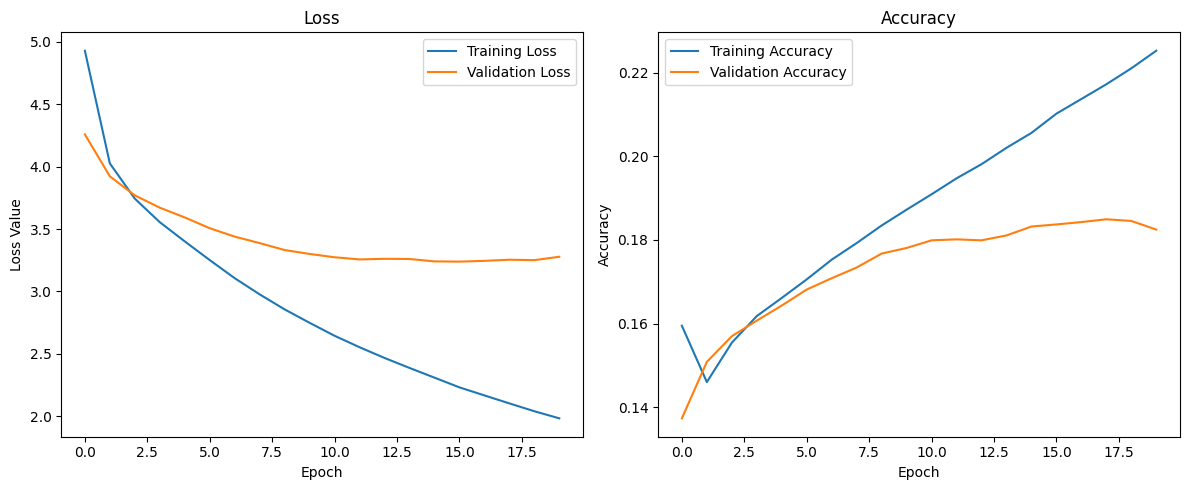

Evaluating the model on test dataset...
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 551ms/step - accuracy: 0.1850 - loss: 3.3124
Test Loss: 3.2780
Test Accuracy: 0.1853
Saving models...
Models saved to /tf/projet/Leyanda_Project/models/saved
Model training complete!


In [43]:
## MODELS TRAINING WORKFLOW
print(f"Starting model training workflow for {project_name}...")

# 1. Create callbacks
callbacks = create_callbacks(
    model_name=f"{project_name}_captioning",
    tensorboard=True,
    early_stopping=True,
    model_checkpoint=True
)
wandb_callback = wandb.keras.WandbMetricsLogger()
callbacks.append(wandb_callback)
if BLEU:
    bleu_callback = BLEUCallback(
        val_img_paths[:100],
        val_captions[:100],
        tokenizer,
        max_length,
        save_path
    )
    callbacks.append(bleu_callback)

# 2. Train the model
print(f"Training the model for {epochs} epochs...")
history = captioning_model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=2
)

# 3. Log training metrics
plot_training_history(history)

# 4. Evaluate the model on validation dataset
print("Evaluating the model on test dataset...")
results = captioning_model.evaluate(test_dataset)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")

# 5. Log final metrics to wandb
wandb.log({
    "final_test_loss": results[0],
    "final_test_accuracy": results[1]
})

# 6. Save the models
print("Saving models...")
os.makedirs(save_path, exist_ok=True)
captioning_model.save(os.path.join(f"{save_path}/full", f"{project_name}_captioning_model_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.keras"))
encoder.save(os.path.join(f"{save_path}/encoder", f"{project_name}_encoder_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.keras"))
decoder.save(os.path.join(f"{save_path}/decoder", f"{project_name}_decoder_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.keras"))
print(f"Models saved to {save_path}")

print("Model training complete!")

In [ ]:
## MODELS RETRAINING WORKFLOW
loaded_model = tf.keras.models.load_model("")

history = loaded_model.fit(
    train_dataset,
    epochs=30,  # Number of epochs
    initial_epoch=15,  # Begins from epoch n
    validation_data=val_dataset,
    callbacks=callbacks
)

Starting inference workflow for Leyanda...


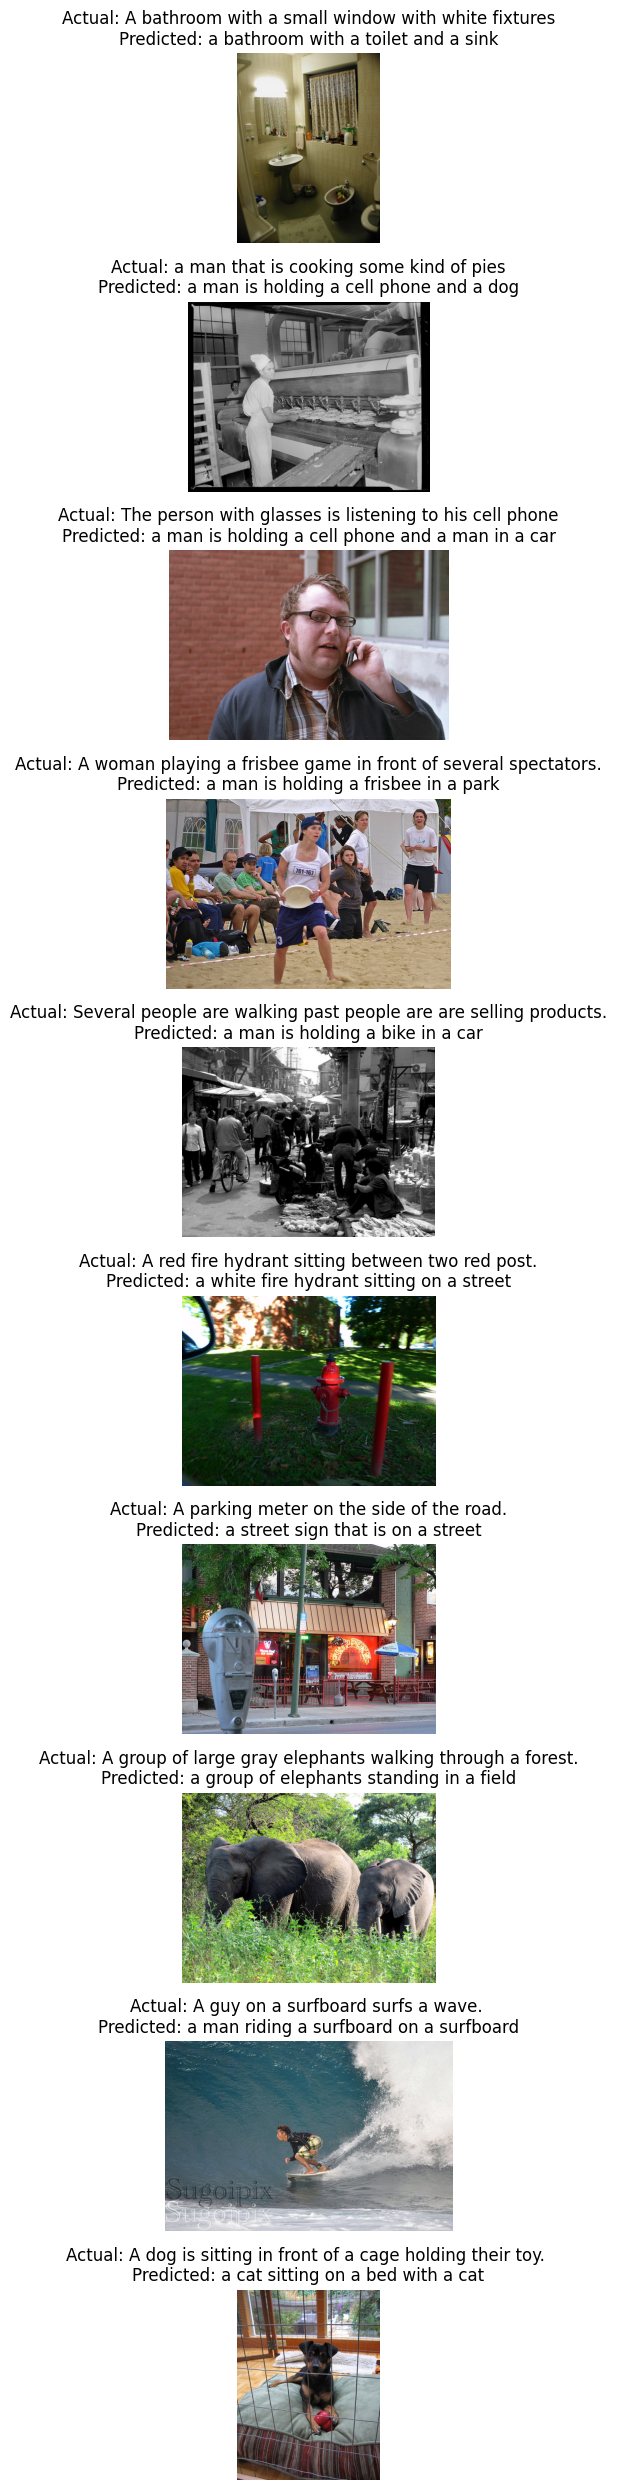

Inference complete!


In [45]:
## INFERENCE WORKFLOW
print(f"Starting inference workflow for {project_name}...")

num_examples = 10
test_indices = np.random.choice(len(test_img_paths), num_examples, replace=False)

plt.figure(figsize=(15, 25))

for i, idx in enumerate(test_indices):
    img_path = test_img_paths[idx]
    actual_caption = test_captions[idx]
    predicted_caption = generate_caption(img_path, captioning_model, tokenizer, max_length)

    plt.subplot(num_examples, 1, i+1)
    img = plt.imread(img_path)
    plt.imshow(img)
    plt.title(f'Actual: {actual_caption}\nPredicted: {predicted_caption}', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(save_path, f"{project_name}_examples.png"))
plt.show()

print("Inference complete!")